In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import lightgbm
import optuna

print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("optuna:", optuna.__version__)

pandas: 3.0.3
sklearn: 1.9.0
xgboost: 3.2.0
lightgbm: 4.6.0
optuna: 4.9.0


c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import lightgbm
import optuna
import gc
import os

# Paths
snp_path  = r"C:\Users\user\Downloads\GSE148375_processed_data (1).txt\GSE148375_processed_data.txt"
meta_path = r"C:\Users\user\Downloads\GSE148375_series_matrix (1).txt\GSE148375_series_matrix (1).txt"
ckpt      = r"C:\Users\user\smoker-no-smoker\checkpoints\\"

os.makedirs(ckpt, exist_ok=True)

print("snp_path exists:", os.path.exists(snp_path))
print("meta_path exists:", os.path.exists(meta_path))
print("checkpoint folder:", os.path.exists(ckpt))

snp_path exists: True
meta_path exists: True
checkpoint folder: True


In [3]:
gsm_ids, descriptions, statuses = [], [], []

with open(meta_path, encoding="utf-8") as f:
    for line in f:
        if "!Sample_geo_accession" in line:
            gsm_ids = [v.strip().strip('"') for v in line.strip().split("\t")[1:]]
        if "!Sample_description" in line:
            descriptions = [v.strip().strip('"') for v in line.strip().split("\t")[1:]]
        if "smoking_status" in line.lower():
            statuses = [v.split(":")[-1].strip().strip('"') for v in line.strip().split("\t")[1:]]

meta = pd.DataFrame({
    "gsm_id": gsm_ids,
    "sample_id": descriptions,
    "smoking_status": statuses
})

# Drop ex-smokers immediately
meta = meta[meta["smoking_status"] != "Ex-smoker"].reset_index(drop=True)

print(meta.shape)
print(meta["smoking_status"].value_counts())

(3396, 3)
smoking_status
Non-smoker    1740
Smoker        1656
Name: count, dtype: int64


In [5]:
ckpt_imputed = ckpt + 'X_imputed.parquet'
ckpt_y       = ckpt + 'y.csv'

if os.path.exists(ckpt_imputed):
    print("Checkpoint found — loading...")
    X_imputed = pd.read_parquet(ckpt_imputed)
    y = pd.read_csv(ckpt_y, index_col=0).squeeze()
    print(f"X_imputed: {X_imputed.shape}, y: {y.shape}")

else:
    # Save y
    y = (meta["smoking_status"] == "Smoker").astype(int)
    y.index = meta["sample_id"].tolist()
    y.name = "smoking_status"
    y.to_csv(ckpt_y)

    sample_ids = meta["sample_id"].tolist()

    def encode_chunk(chunk):
        chunk = chunk[sample_ids].T
        chunk.index = sample_ids
        def encode_col(col):
            valid = col[col != "NC"]
            if len(valid) == 0:
                return pd.Series(np.nan, index=col.index, dtype="float32")
            allele_counts = {}
            for gt in valid:
                for allele in gt:
                    allele_counts[allele] = allele_counts.get(allele, 0) + 1
            if len(allele_counts) < 2:
                return pd.Series(0.0, index=col.index, dtype="float32")
            minor_allele = min(allele_counts, key=allele_counts.get)
            def count_minor(gt):
                if gt == "NC":
                    return np.nan
                return float(gt.count(minor_allele))
            return col.map(count_minor).astype("float32")
        return chunk.apply(encode_col)

    def compute_maf(col):
        valid = col.dropna()
        if len(valid) == 0:
            return 0
        minor_count = min(
            (valid == 0).sum() * 2 + (valid == 1).sum(),
            (valid == 2).sum() * 2 + (valid == 1).sum()
        )
        return minor_count / (len(valid) * 2)

    chunk_size = 5000
    kept_chunks = []
    chunk_num = 0

    print("Loading, encoding and applying QC in chunks...")
    for chunk in pd.read_csv(snp_path, sep="\t", index_col=0,
                              encoding="utf-8", chunksize=chunk_size):
        encoded = encode_chunk(chunk)

        # QC Filter 1 — missing rate
        encoded = encoded.loc[:, encoded.isna().mean() <= 0.10]

        # QC Filter 2 — monomorphic
        encoded = encoded.loc[:, encoded.nunique() > 1]

        # QC Filter 3 — MAF
        maf = encoded.apply(compute_maf)
        encoded = encoded.loc[:, maf >= 0.05]

        if encoded.shape[1] > 0:
            kept_chunks.append(encoded)

        chunk_num += 1
        print(f"Chunk {chunk_num}/49 done — kept so far: {sum(c.shape[1] for c in kept_chunks)}", end="\r")

        del chunk, encoded
        gc.collect()

    print("\nCombining chunks...")
    X_qc = pd.concat(kept_chunks, axis=1)
    del kept_chunks
    gc.collect()
    print(f"After QC: {X_qc.shape}")

    # Imputation — mean (only 0.30% missing)
    print("Imputing...")
    col_means = X_qc.mean()
    X_imputed = X_qc.fillna(col_means).astype("float32")

Loading, encoding and applying QC in chunks...
Chunk 49/49 done — kept so far: 31127
Combining chunks...
After QC: (3396, 31127)
Imputing...


In [6]:
print(X_imputed.shape)
print(X_imputed.isna().sum().sum())
print(os.path.exists(ckpt + 'X_imputed.parquet'))

(3396, 31127)
0
False


In [7]:
X_imputed.to_parquet(ckpt + 'X_imputed.parquet')
y.to_csv(ckpt + 'y.csv')
print("Saved successfully")
print(os.path.exists(ckpt + 'X_imputed.parquet'))

Saved successfully
True


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Save train/test sets
X_train.to_parquet(ckpt + 'X_train.parquet')
X_test.to_parquet(ckpt + 'X_test.parquet')
y_train.to_csv(ckpt + 'y_train.csv')
y_test.to_csv(ckpt + 'y_test.csv')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train:\n{y_train.value_counts()}")
print(f"y_test:\n{y_test.value_counts()}")

X_train: (2716, 31127)
X_test:  (680, 31127)
y_train:
smoking_status
0    1392
1    1324
Name: count, dtype: int64
y_test:
smoking_status
0    348
1    332
Name: count, dtype: int64


In [10]:
from sklearn.feature_selection import SelectKBest, chi2

# Keep top 5000 SNPs by chi-square with smoking label
# Takes ~1-2 min, then elastic net on 5k features is fast (~3-5 min on CPU)
selector = SelectKBest(chi2, k=5000)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print(f"Reduced: {X_train_selected.shape}")

Reduced: (2716, 5000)


In [11]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

# Scale
scaler = StandardScaler(with_std=False)
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled  = scaler.transform(X_test_selected)

# Elastic Net CV
enet = LogisticRegressionCV(
    cv=5,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.5],
    max_iter=500,
    tol=1e-3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
enet.fit(X_train_scaled, y_train)

# Evaluate
y_pred_proba = enet.predict_proba(X_test_scaled)[:, 1]
y_pred = enet.predict(X_test_scaled)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC:  {auc:.4f}")
print(f"SNPs with non-zero coef: {(enet.coef_[0] != 0).sum()}")
print(classification_report(y_test, y_pred))

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-lea

AUC:  0.5058
SNPs with non-zero coef: 5000
              precision    recall  f1-score   support

           0       0.51      0.51      0.51       348
           1       0.49      0.48      0.49       332

    accuracy                           0.50       680
   macro avg       0.50      0.50      0.50       680
weighted avg       0.50      0.50      0.50       680



In [1]:
import pandas as pd
import numpy as np

ckpt = r'C:\Users\user\smoker-no-smoker\checkpoints\\'

# Load
X_imputed = pd.read_parquet(ckpt + 'X_imputed.parquet')
y = pd.read_csv(ckpt + 'y.csv', index_col=0).squeeze()
X_train = pd.read_parquet(ckpt + 'X_train.parquet')
X_test = pd.read_parquet(ckpt + 'X_test.parquet')
y_train = pd.read_csv(ckpt + 'y_train.csv', index_col=0).squeeze()
y_test = pd.read_csv(ckpt + 'y_test.csv', index_col=0).squeeze()

print(f"X_imputed: {X_imputed.shape}")
print(f"y: {y.shape}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_imputed: (3396, 31127)
y: (3396,)
X_train: (2716, 31127), X_test: (680, 31127)


In [3]:
! pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.

Explained variance ratio (each PC):
  PC1: 0.0193 (1.93%)
  PC2: 0.0033 (0.33%)
  PC3: 0.0030 (0.30%)
  PC4: 0.0026 (0.26%)
  PC5: 0.0021 (0.21%)
  PC6: 0.0019 (0.19%)
  PC7: 0.0019 (0.19%)
  PC8: 0.0017 (0.17%)
  PC9: 0.0016 (0.16%)
  PC10: 0.0016 (0.16%)
  PC11: 0.0015 (0.15%)
  PC12: 0.0015 (0.15%)
  PC13: 0.0015 (0.15%)
  PC14: 0.0015 (0.15%)
  PC15: 0.0014 (0.14%)
  PC16: 0.0014 (0.14%)
  PC17: 0.0013 (0.13%)
  PC18: 0.0013 (0.13%)
  PC19: 0.0013 (0.13%)
  PC20: 0.0013 (0.13%)

Total variance explained: 5.30%


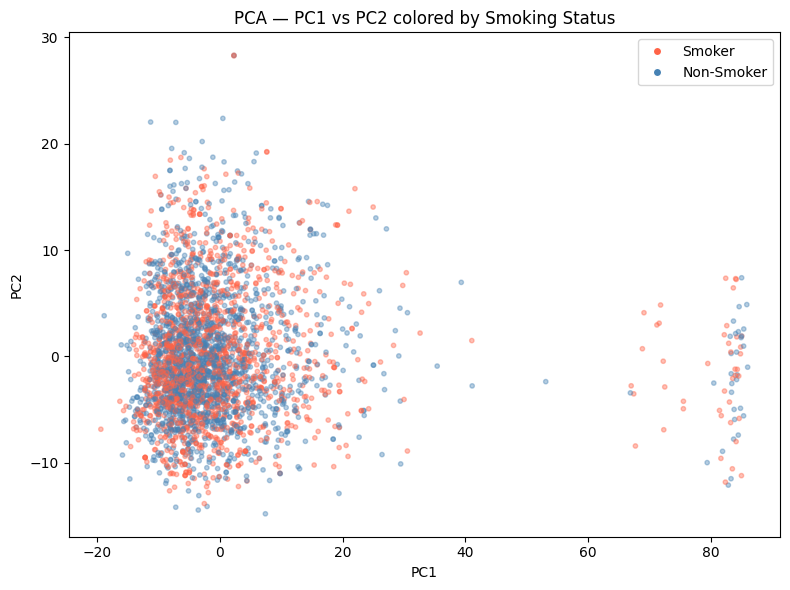

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Scale
scaler = StandardScaler(with_std=False)
X_scaled = scaler.fit_transform(X_imputed)

# Step 2: PCA with 20 components
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio (each PC):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"\nTotal variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Step 3: Plot PC1 vs PC2 colored by smoking status
plt.figure(figsize=(8, 6))
colors = y.map({0: 'steelblue', 1: 'tomato'})
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA — PC1 vs PC2 colored by Smoking Status')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', label='Smoker'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', label='Non-Smoker')
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('pca_smoking.png', dpi=150)
plt.show()

In [3]:
# Define path
meta_path = r"C:\Users\user\Downloads\GSE148375_series_matrix (1).txt\GSE148375_series_matrix (1).txt"

# Extract ALL metadata fields from series matrix
meta_fields = {}

with open(meta_path, encoding='utf-8') as f:
    for line in f:
        if line.startswith('!Sample_'):
            key = line.split('\t')[0].strip()
            values = [v.strip().strip('"') for v in line.strip().split('\t')[1:]]
            if key not in meta_fields:
                meta_fields[key] = values

# Show all available fields
for key, values in meta_fields.items():
    unique_vals = list(set(values))[:5]
    print(f"{key}\n  → {unique_vals}\n")

!Sample_title
  → ['Blood, Smoker_432', 'Blood, Non-smoker_662', 'Blood, Non-smoker_437', 'Blood, Smoker_2153', 'Blood, Non-smoker_147']

!Sample_geo_accession
  → ['GSM4463530', 'GSM4463745', 'GSM4464752', 'GSM4464911', 'GSM4465688']

!Sample_status
  → ['Public on Apr 10 2020']

!Sample_submission_date
  → ['Apr 09 2020']

!Sample_last_update_date
  → ['Apr 10 2020']

!Sample_type
  → ['genomic']

!Sample_channel_count
  → ['1']

!Sample_source_name_ch1
  → ['Blood']

!Sample_organism_ch1
  → ['Homo sapiens']

!Sample_characteristics_ch1
  → ['ethnicity: African-American']

!Sample_molecule_ch1
  → ['genomic DNA']

!Sample_extract_protocol_ch1
  → ['Genomic DNA was extracted from EDTA-treated peripheral venous blood of each subject using the Qiagen DNA purification kit. All DNA samples were treated with RNase A to remove potential contaminating RNA, and DNA quality and the concentration of each sample was determined by the A260/A280 absorbance ratio.']

!Sample_label_ch1
  → ['cy3, c

In [5]:
meta_path = r"C:\Users\user\Downloads\GSE148375_series_matrix (1).txt\GSE148375_series_matrix (1).txt"

gsm_ids = []
characteristics_lines = []

with open(meta_path, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if '!Sample_geo_accession' in line:
            gsm_ids = [v.strip().strip('"') for v in line.split('\t')[1:]]
        if '!Sample_characteristics_ch1' in line:
            # collect ALL lines with this tag
            values = [v.strip().strip('"') for v in line.split('\t')[1:]]
            characteristics_lines.append(values)

# Each line in characteristics_lines is one variable across all patients
print(f"Number of characteristic rows found: {len(characteristics_lines)}")
print(f"Number of patients: {len(gsm_ids)}")
print()
for row in characteristics_lines:
    print(f"  {row[0]}")  # print first patient's value to see the key

Number of characteristic rows found: 8
Number of patients: 3399

  ethnicity: African-American
  age: 39
  gender: Male
  cpd: 20
  hsi: 4
  ftnd: 7
  smoking_status: Smoker
  tissue: Blood
